In [33]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


In [34]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')
datos_penguins = datos_penguins.dropna()

Que preguntas me hago respecto a esto?
- Los pinguinos estan en todas las islas? O las especies residen en islas en particular?
- Hay diferencias en las cualidades fisicas entre los pinguinos femenino y masculino de las especies?
- Se relaciona en algo el lugar donde fueron tomadas las mediciones, con su tamaño?
- Los pinguinos, se mueven entre estas islas? Es decir, las mediciones, si hubieran sido tomadas al dia siguiente, puede un pinguino haber estado en otra de estas islas? O son inaccesibles entre si?

In [35]:
categoricas = datos_penguins.select_dtypes(include=['object', 'category'])
categoricas.value_counts()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14712\303131875.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = datos_penguins.select_dtypes(include=['object', 'category'])


species    island     sex   
Gentoo     Biscoe     Male      61
                      Female    58
Chinstrap  Dream      Female    34
                      Male      34
Adelie     Dream      Male      28
                      Female    27
           Torgersen  Female    24
                      Male      23
           Biscoe     Female    22
                      Male      22
Name: count, dtype: int64

Las razas Gento y Chinstrap aparecen en una sola isla. La raza Adelie es la unica que aparece en la isla Torgensen, por lo que es un buen atributo para identificar varios ejemplares.

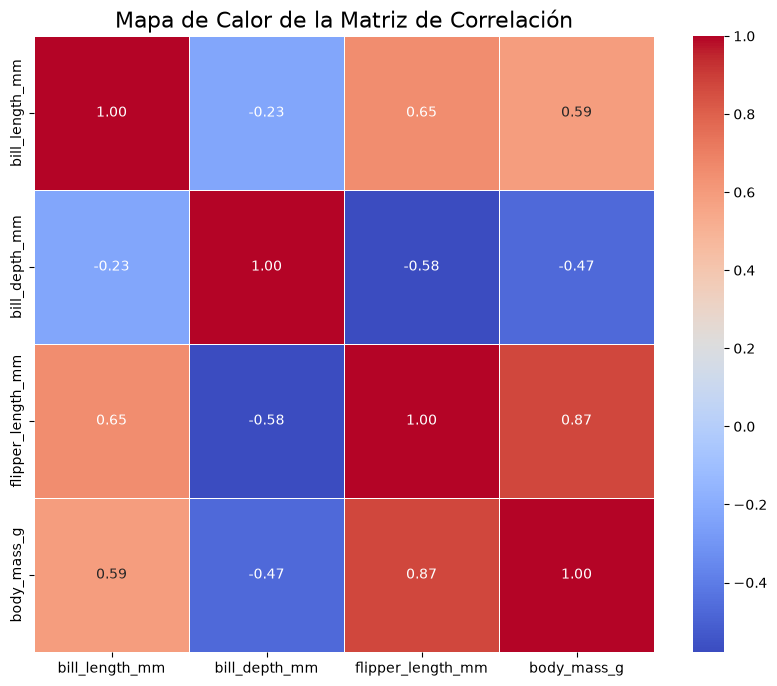

In [36]:
# Calcular la matriz de correlación
matriz_corr = datos_penguins.select_dtypes(include=['float64', 'int64']).corr()

# Visualización con Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de la Matriz de Correlación', fontsize=16)
plt.show()

Esta matriz se ve bastante rara: sin previo analisis, uno diria que para "los pinguinos del archipielago palmer", las variables relacionadas a las dimensiones del pico, estan poco correlacionadas, en comparacion a el peso y el tamaño de la aleta cuando uno lo que tenderia a pensar es que "Pinguino mas grande -> pico mas grande", por lo que espero esto sea producto de algun factor no 

Quiero ver esta misma matriz, pero separada por especies!

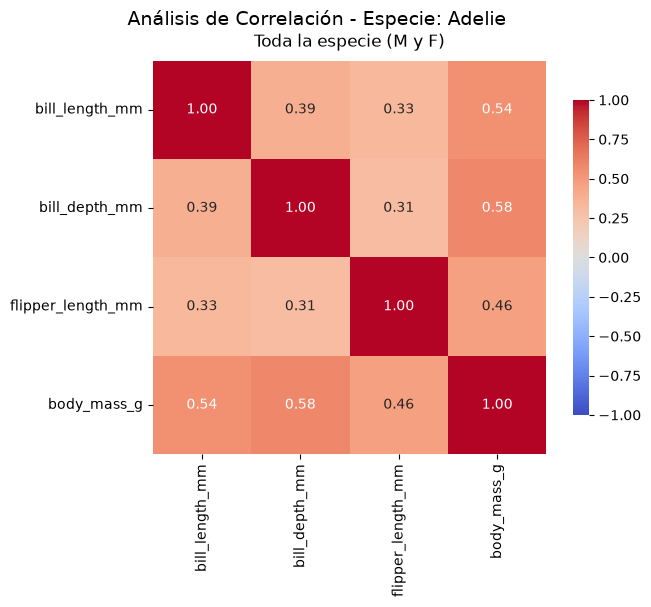

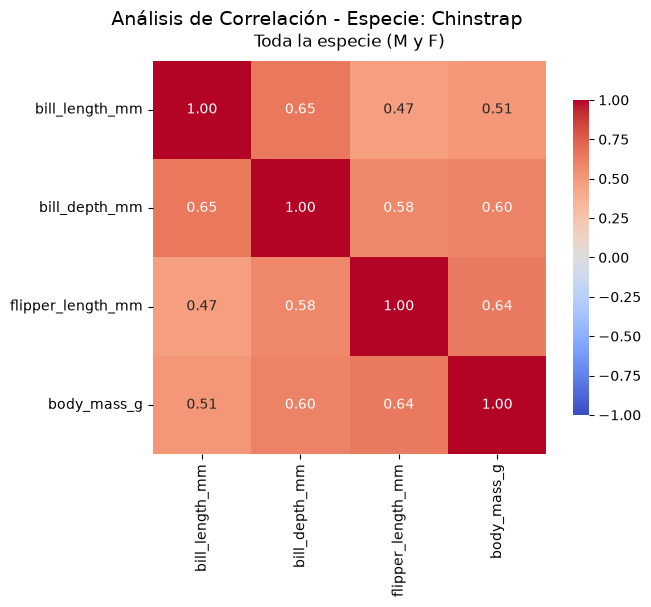

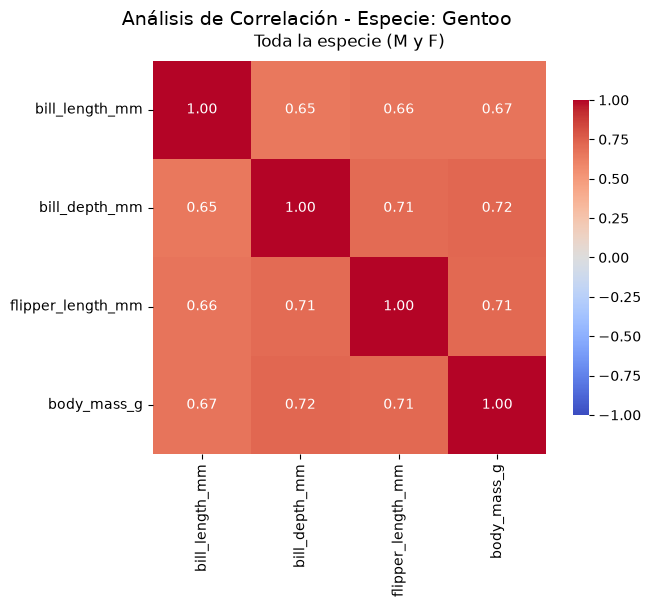

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Se obtienen las especies únicas del dataset
especies = datos_penguins['species'].dropna().unique()

for especie in especies:
    # 1. Configurar la figura con un solo eje (1 gráfico)
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.suptitle(f"Análisis de Correlación - Especie: {especie}", fontsize=14, y=0.98)
    
    # 2. Filtrado y cálculo de correlación
    df_especie = datos_penguins[datos_penguins['species'] == especie]
    num_especie = df_especie.select_dtypes(include=[np.number])
    matriz_total = num_especie.corr()
    
    # 3. Generación del Heatmap en el eje único
    sns.heatmap(
        matriz_total, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        vmin=-1, vmax=1, 
        square=True,
        cbar_kws={'shrink': 0.8},
        ax=ax
    )
    ax.set_title("Toda la especie (M y F)", pad=10)
    
    plt.tight_layout()
    plt.show()

Se ven variables relacionadas positivamente, todas con valores similares, lo cual tiene -> A mas grande algo, mas grande las demas caracteristicas por especie

Pero este -0.23 en la variable para todos los datos tiene que tener algun significado... veamos el scatter.

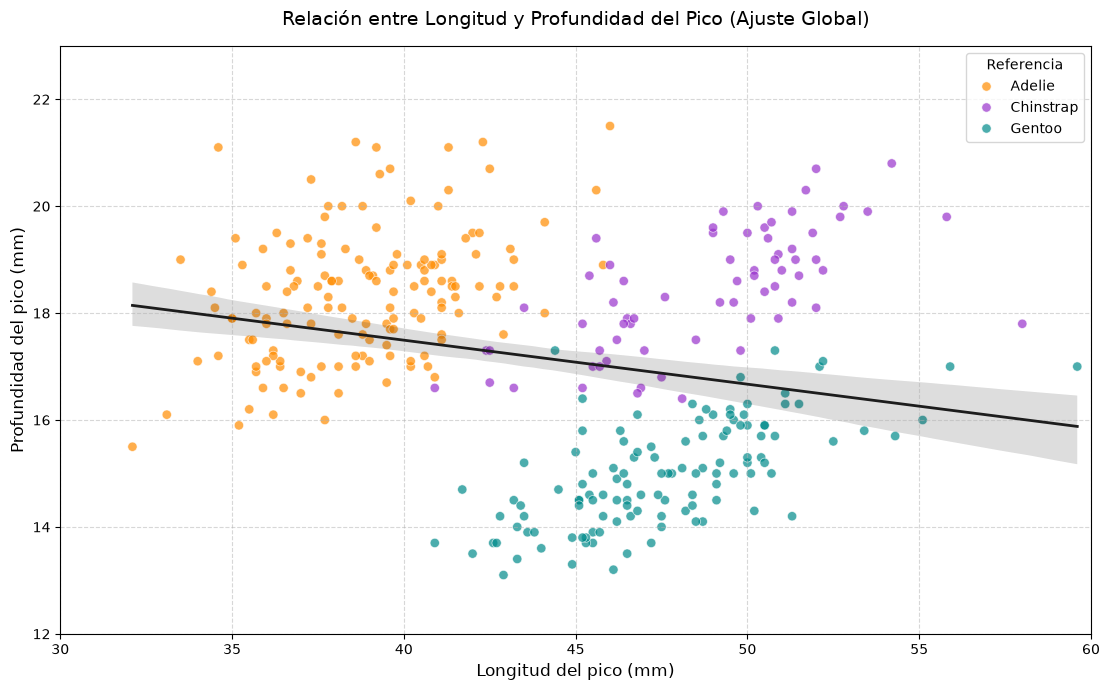

Ecuación de regresión global y Coeficiente de Determinación (R²):
  y = -0.0823x + (20.7866)
  R² = 0.0523 (r = -0.2286, p-valor = 2.528e-05)


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# 1. Paleta personalizada
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

# 2. Gráfico
fig, ax = plt.subplots(figsize=(11.2, 7))

# Puntos diferenciados por especie
sns.scatterplot(
    data=datos_penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette=paleta_penguins,
    alpha=0.7,
    s=45,
    ax=ax,
)

# Ajuste lineal global ajustado al rango real de los datos (truncate=True)
sns.regplot(
    data=datos_penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    scatter=False,
    color="#1C1C1C",
    truncate=True,
    ax=ax,
    line_kws={'linewidth': 2, 'linestyle': '-', 'label': 'Ajuste global'},
)

# Límites ajustados al dominio de las variables (evita distorsión de escala)
ax.set_xlim(30, 60)
ax.set_ylim(12, 23)

# Título y etiquetas
ax.set_title(
    "Relación entre Longitud y Profundidad del Pico (Ajuste Global)",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Longitud del pico (mm)", fontsize=12)
ax.set_ylabel("Profundidad del pico (mm)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Referencia")

plt.tight_layout()
plt.show()

# 3. Cálculo de la regresión global
df_filtrado = datos_penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm'])

x = df_filtrado['bill_length_mm']
y = df_filtrado['bill_depth_mm']

regresion = linregress(x, y)
m = regresion.slope
b = regresion.intercept
r2 = regresion.rvalue**2
p_val = regresion.pvalue

print("Ecuación de regresión global y Coeficiente de Determinación (R²):")
print(f"  y = {m:.4f}x + ({b:.4f})")
print(f"  R² = {r2:.4f} (r = {regresion.rvalue:.4f}, p-valor = {p_val:.3e})")

Ahi esta el -0.23! los puntos caen en la parte superior izquierda para una especie, e inferior derecha para otra, por lo que la correlacion tiende a ser negativa.

Veamos los arreglos lineales para las especies por separado

Correlaciones (pandas.corr):
                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.228626
bill_depth_mm        -0.228626       1.000000
--------------------------------------------------
Correlación Global:
r = -0.2286 | p-valor = 2.5283e-05
--------------------------------------------------
Correlación por Especie:
Adelie     -> r = 0.3858 | p-valor = 1.5149e-06
Chinstrap  -> r = 0.6535 | p-valor = 1.5255e-09
Gentoo     -> r = 0.6540 | p-valor = 7.3366e-16


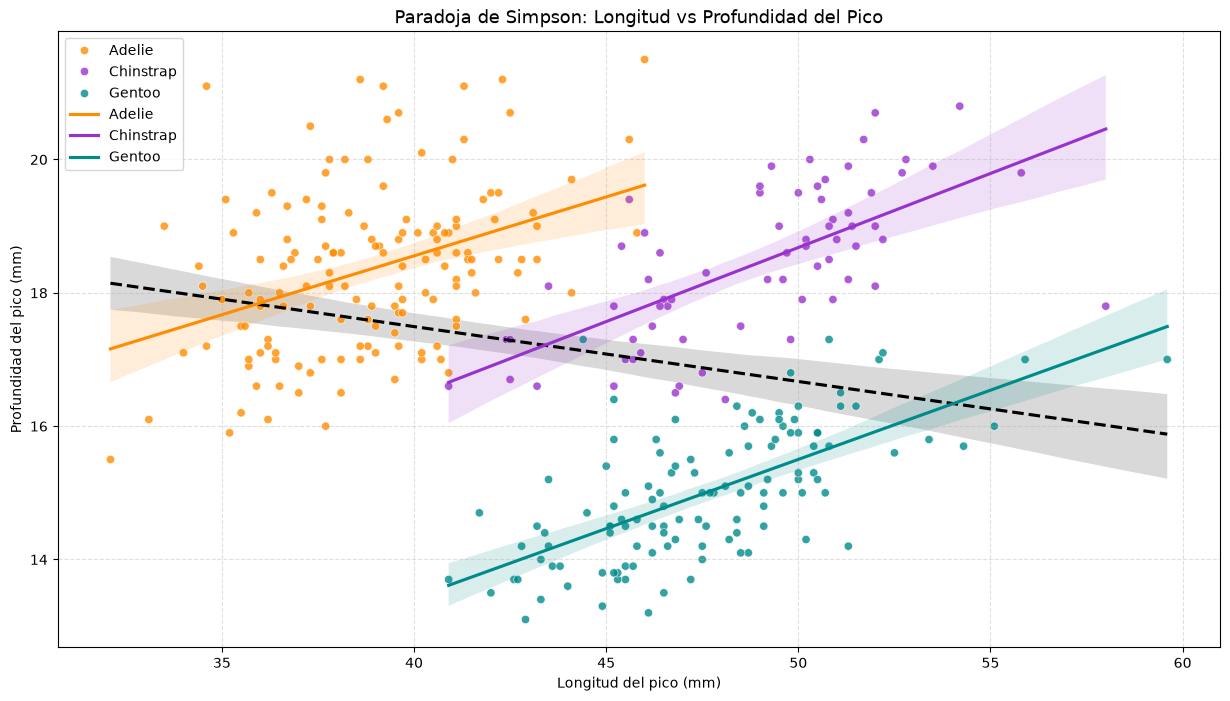

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = datos_penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

print("Correlaciones (pandas.corr):")
print(df[['bill_length_mm', 'bill_depth_mm']].corr())
print("-" * 50)

# coeficiente de pearson y p-valor para todos
r_global, p_global = pearsonr(df['bill_length_mm'], df['bill_depth_mm'])
print(f"Correlación Global:")
print(f"r = {r_global:.4f} | p-valor = {p_global:.4e}")
print("-" * 50)

# pr especie
print("Correlación por Especie:")
for especie, grupo in df.groupby('species'):
    r_esp, p_esp = pearsonr(grupo['bill_length_mm'], grupo['bill_depth_mm'])
    print(f"{especie:10s} -> r = {r_esp:.4f} | p-valor = {p_esp:.4e}")
fig, ax = plt.subplots(figsize=(15, 8))

# Regresión global (línea punteada negra)
sns.regplot(
    data=df, x="bill_length_mm", y="bill_depth_mm",
    scatter=False, ax=ax, color='black',
    line_kws={'linestyle': '--', 'label': f'Global (r={r_global:.2f})'}
)

# Regresiones por especie
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", palette=paleta_penguins, ax=ax, alpha=0.8)
for especie, color in paleta_penguins.items():
    sub = df[df['species'] == especie]
    sns.regplot(data=sub, x="bill_length_mm", y="bill_depth_mm", scatter=False, ax=ax, color=color, label=especie)

ax.set_title("Paradoja de Simpson: Longitud vs Profundidad del Pico", fontsize=13)
ax.set_xlabel("Longitud del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

Matriz de correlación global (pandas.corr):
                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.228626
bill_depth_mm        -0.228626       1.000000
--------------------------------------------------
Correlación Global:
r = -0.2286 | p-valor = 2.5283e-05
--------------------------------------------------
Correlación por Especie:
Adelie     -> r = 0.3858 | p-valor = 1.5149e-06
Chinstrap  -> r = 0.6535 | p-valor = 1.5255e-09
Gentoo     -> r = 0.6540 | p-valor = 7.3366e-16


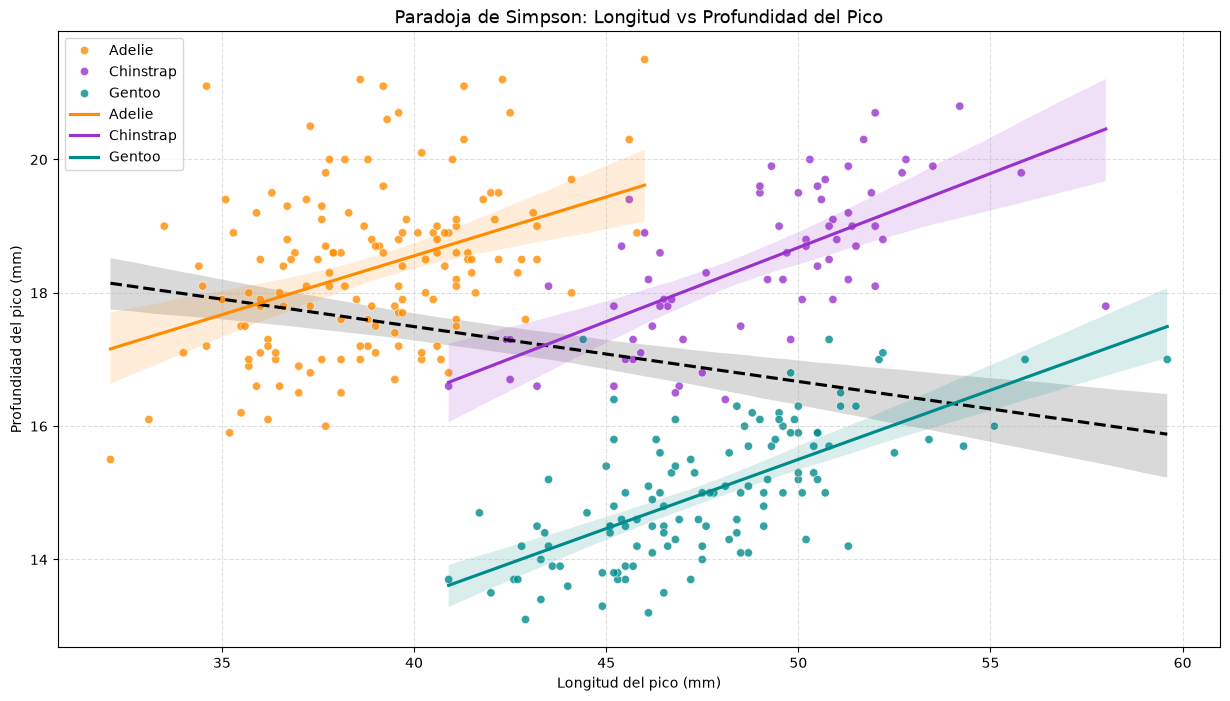

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Limpieza de datos
df = datos_penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

# 2. Matriz de correlación con pandas
print("Matriz de correlación global (pandas.corr):")
print(df[['bill_length_mm', 'bill_depth_mm']].corr())
print("-" * 50)

# 3. Coeficiente global y significancia estadística (scipy.stats.pearsonr)
r_global, p_global = pearsonr(df['bill_length_mm'], df['bill_depth_mm'])
print(f"Correlación Global:")
print(f"r = {r_global:.4f} | p-valor = {p_global:.4e}")
print("-" * 50)

# 4. Coeficientes por especie y significancia estadística
print("Correlación por Especie:")
for especie, grupo in df.groupby('species'):
    r_esp, p_esp = pearsonr(grupo['bill_length_mm'], grupo['bill_depth_mm'])
    print(f"{especie:10s} -> r = {r_esp:.4f} | p-valor = {p_esp:.4e}")

# 5. Visualización: Contraste Global vs Por Especie
fig, ax = plt.subplots(figsize=(15, 8))

# Regresión global (línea punteada negra)
sns.regplot(
    data=df, x="bill_length_mm", y="bill_depth_mm",
    scatter=False, ax=ax, color='black',
    line_kws={'linestyle': '--', 'label': f'Global (r={r_global:.2f})'}
)

# Regresiones por especie
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", palette=paleta_penguins, ax=ax, alpha=0.8)
for especie, color in paleta_penguins.items():
    sub = df[df['species'] == especie]
    sns.regplot(data=sub, x="bill_length_mm", y="bill_depth_mm", scatter=False, ax=ax, color=color, label=especie)

ax.set_title("Paradoja de Simpson: Longitud vs Profundidad del Pico", fontsize=13)
ax.set_xlabel("Longitud del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

Bastante mas coherente! Para las 3, el hecho de que aumente una caracteristica, hace que aumente la otra.

Ademas, vemos significancias estadisticas para los tests hechos

Veamos ahora las distribuciones de las variables

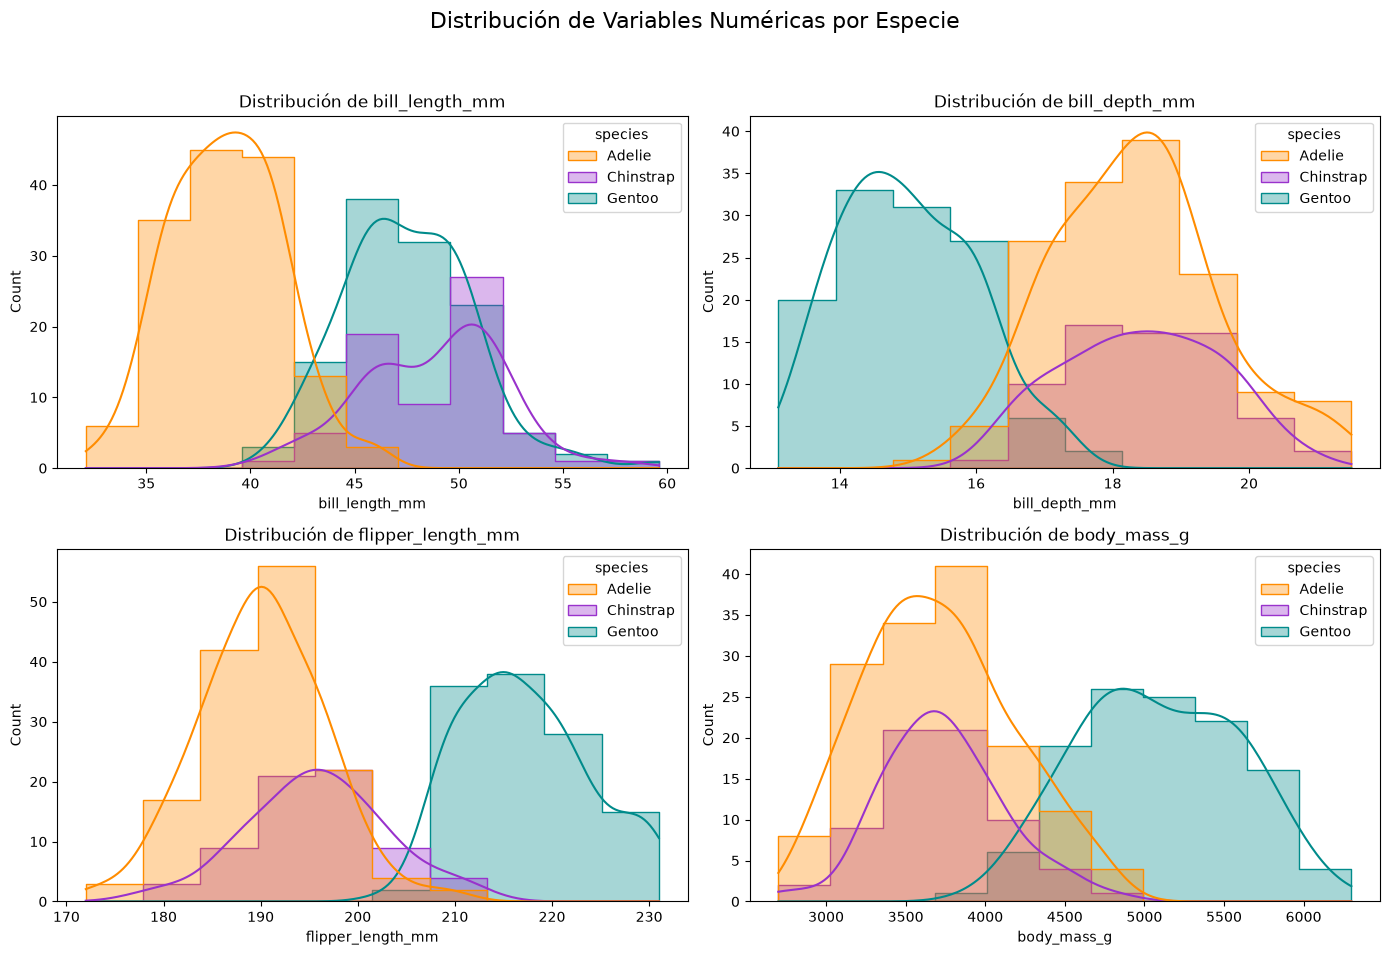

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = datos_penguins.select_dtypes(include=['float64', 'int64']).columns

# Paleta específica de alto contraste y balance estético
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    ax = axes[i // 2, i % 2]
    
    sns.histplot(
        data=datos_penguins,
        x=col,
        hue='species',
        kde=True,
        ax=ax,
        palette=paleta_penguins,
        alpha=0.35,
        element="step",       # Delinea los bordes evitando que las barras se tapen
        common_norm=False     # Normaliza la densidad de cada especie de forma independiente
    )
    ax.set_title(f'Distribución de {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Aca podemos ver mejor en comparacion a los graficos univariados! Vemos que la especie Gentoo es la que estaba generando las colas pesadas, debido a que tiene un numero similar de muestras que la Adelie, y son bastantes separables por el tamaño de los pinguinos en general! (Mas peso, mayor tamaño de aleta, y largo de pico), peeeero, tiene una peculiaridad: el alto de su pico es mas corto, por lo que me imagino una especie de pinguino con un pico mas "alapisado". 

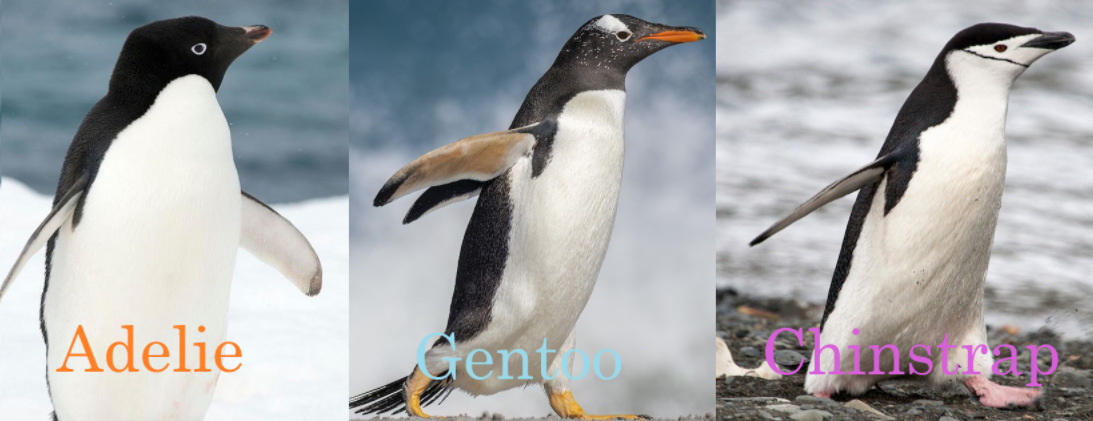

Efectivamente!! Son pinguinos mas grandotes, con el pico un poco mas fino y largo. Ademas, al ver la foto, pienso que hay una correlacion similar en el crecimiento entre las 2 variables relacionadas al pico en las especies de Gentoo y Chinstrap, que al ver el grafico de correlaciones se da! (0,65 para ambas)

Podemos ademas, ver los boxplots, cosa de que quede mas claro a la vista

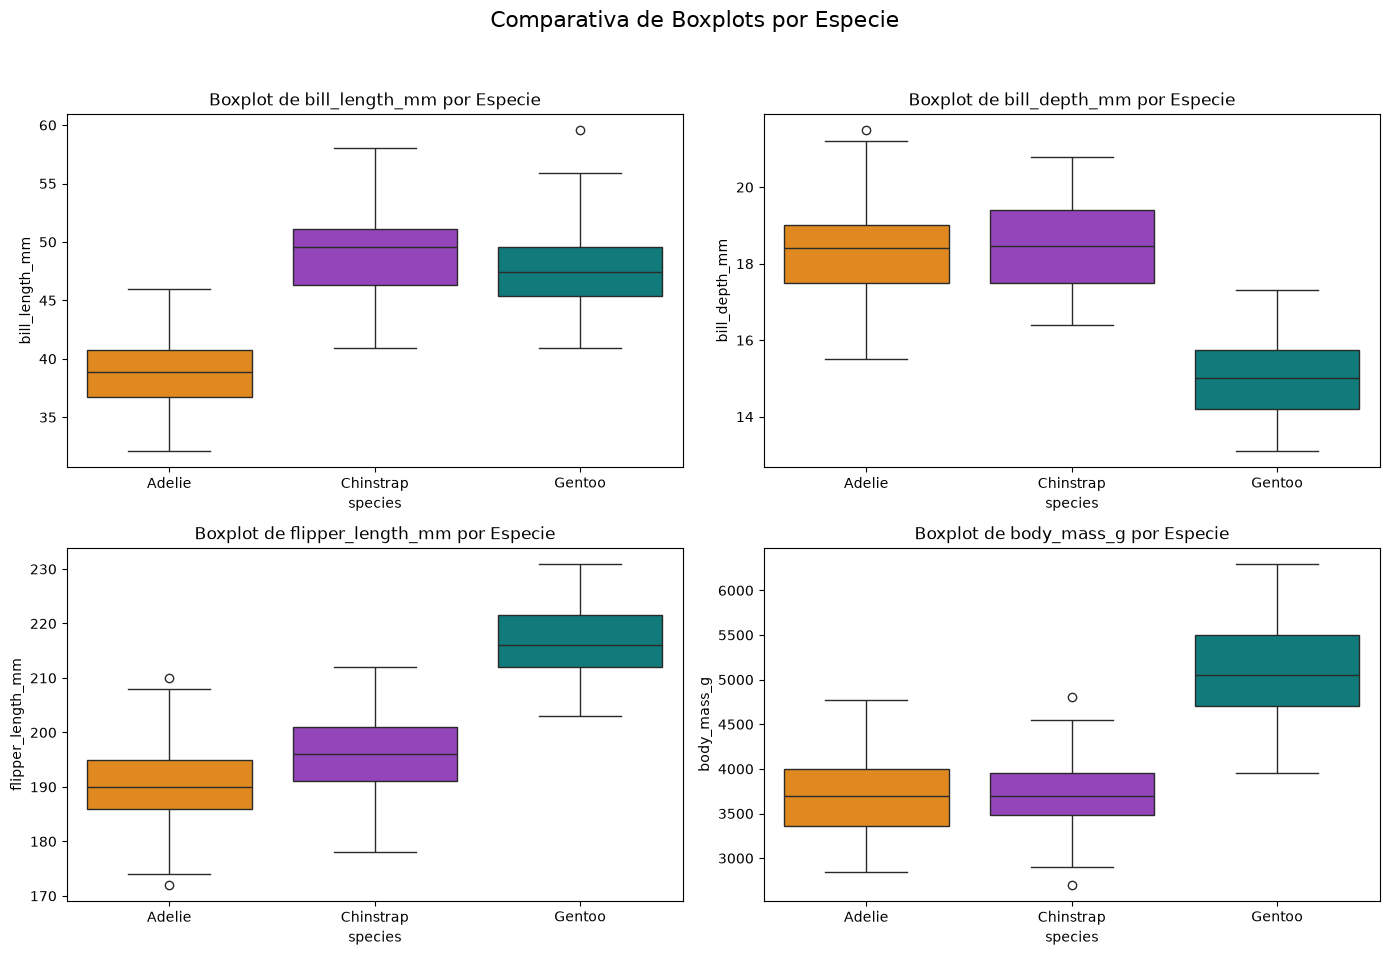

In [42]:
# Boxplots segmentados por especie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Boxplots por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.boxplot(data=datos_penguins, x='species', y=col, hue='species', ax=axes[i//2, i%2], palette=paleta_penguins, legend=False)
    axes[i//2, i%2].set_title(f'Boxplot de {col} por Especie')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Veamos ahora las tablas de contingencia, y el test de chi-cuadrado!

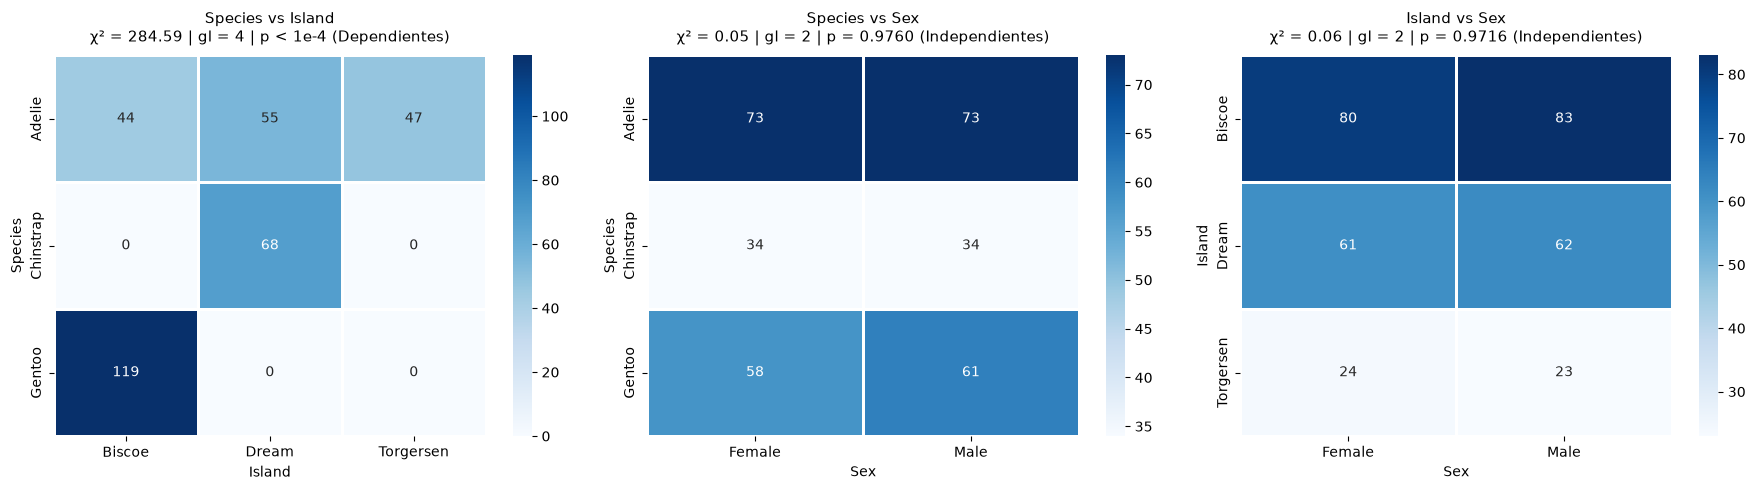

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

# 1. Filtrado de registros completos
df_cat = datos_penguins.dropna(subset=['species', 'island', 'sex'])

pares = [
    ('species', 'island'),
    ('species', 'sex'),
    ('island', 'sex')
]

# 2. Generación de 3 subplots para visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (var1, var2) in zip(axes, pares):
    # Tabla de contingencia
    tabla_obs = pd.crosstab(df_cat[var1], df_cat[var2])
    
    # Test de Independencia Chi-cuadrado
    chi2, p_val, dof, expected = chi2_contingency(tabla_obs)
    
    # Heatmap de frecuencias observadas
    sns.heatmap(
        tabla_obs,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=0.8,
        linecolor='white',
        cbar=True,
        ax=ax
    )
    
    # Formateo del p-valor para el título
    p_text = f"p < 1e-4" if p_val < 0.0001 else f"p = {p_val:.4f}"
    decision = "Dependientes" if p_val < 0.05 else "Independientes"
    
    ax.set_title(
        f"{var1.capitalize()} vs {var2.capitalize()}\n"
        f"χ² = {chi2:.2f} | gl = {dof} | {p_text} ({decision})",
        fontsize=11,
        pad=10
    )
    ax.set_xlabel(var2.capitalize(), fontsize=10)
    ax.set_ylabel(var1.capitalize(), fontsize=10)

plt.tight_layout()
plt.show()

Aqui vemos lo siguiente: La variable de species y island estan correlacionadas estadisticamente, y con justa razon!
    - La especie Gentoo, solo esta en la isla Biscoe
    - La especie Chinstrap, solo esta en la isla Dream
    - La especie Adelie esta en las 3 islas, y aparece de manera exclusiva en la isla Torgersen en el dataset

Un dato bastante peculiar es que la isla Torgensen tiene menos muestras, pero pasa lo siguiente

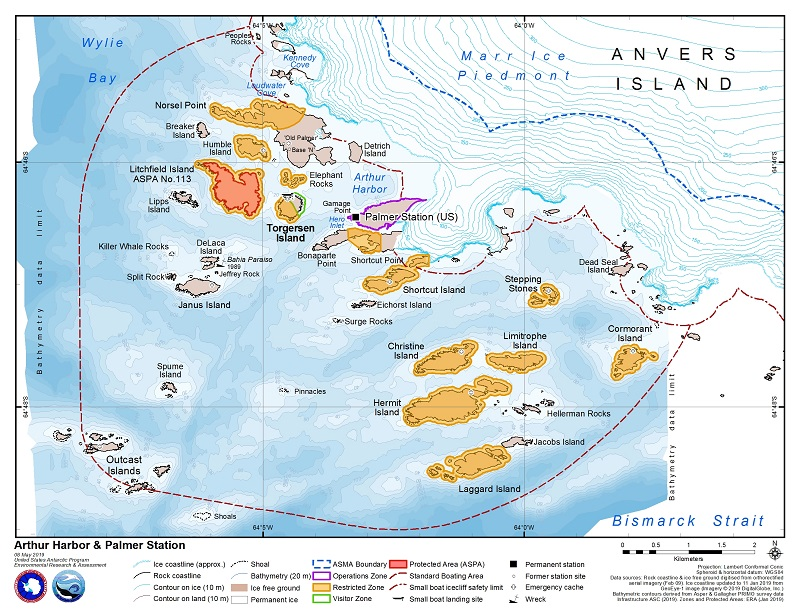

Como se ve en la imagen, la isla Torgensen es la mas cercana a la estacion desde donde se tomaron las muestras, pero la mitad de esta se encuentra dentro del tratado antartico (https://www.ats.aq/devAS/Ats/Guideline/5fb4eff9-a4cb-4366-90d0-e891afdc4963?lang=s), y es el lugar donde se reproducen los pinguinos de Adelie,

Ademas, se estudian esta isla el comportamiento de la especie Adelie, tanto en contacto humano, como sin estar en contacto, estando restringido el acceso a la mitad de la isla

Por otro lado, las muestras entre sexo y especie, y sexo e isla, no tienen significancia estadistica, y se ve bastante claro esto, ya que las columnas no tiene variacion entre si